# CNN (7-Conv) + mRMR + SVM Hybrid
**Pipeline:** Custom 7-layer CNN -> 512-d FC embeddings -> mRMR feature selection (K=96) -> SVM classifier  
All outputs saved to `7conResults/`


In [1]:
# ================================================
# Cell 1 — Imports & Config
# ================================================
# ── Standard library and scientific computing ─────────────────
# os/numpy/pandas/matplotlib/tqdm: I/O, arrays, results, charts
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ── PyTorch and sklearn pipeline ───────────────────────────────
# torch/nn/optim/F: model, layers, optimiser, activations
# sklearn: SVM, StandardScaler, mRMR, joblib
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets


# Evaluation, StandardScaler, SVC, mutual_info_classif, dump
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from joblib import dump


# ── Paths ──────────────────────────────────────────────────────
# Same pre-split dataset as all other CNN experiments.
# ── Paths ──────────────────────────────────────
BASE_DATASET = "/home/jenarththan/Desktop/FYP/May11/Dataset"
TRAIN_PATH   = os.path.join(BASE_DATASET, "Training")
VAL_PATH     = os.path.join(BASE_DATASET, "Validation")
TEST_PATH    = os.path.join(BASE_DATASET, "Testing")

NOTEBOOK_DIR = "/home/jenarththan/Desktop/FYP/May11/Notebooks/Custom"
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, "CNN7_May11_Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ── Hyperparameters ────────────────────────────────────────────
# LR=1e-4    : trained from scratch
# K_MRMR=96  : same as CNN6 — 96 features from the 512-d embedding.
# No ImageNet normalisation — Resize + ToTensor only.
# ── Hyperparameters ─────────────────────────────
CLASS_NAMES     = ['0', '100', '500', '1000', '1500', '2000']
NUM_CLASSES     = len(CLASS_NAMES)
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 50
PATIENCE        = 5
MIN_EPOCHS_BEFORE_STOP = 20
LR              = 1e-4
SEED            = 42
TRAIN_PER_CLASS = 1750
VAL_PER_CLASS   = 250
K_MRMR          = 96
NUM_WORKERS     = 0


# CUDA required; cudnn.benchmark=True for fixed input size
# ── CUDA setup ──────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Check nvidia-smi, then re-run.")

DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# Fix all random seeds for full reproducibility
rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


Output directory: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN7_May11_Results
GPU : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


In [2]:
# ================================================
# Cell 2 — Dataset Loading
# ================================================
# Enforces numeric class order: 0, 100, 500, 1000, 1500, 2000
class OrderedImageFolder(datasets.ImageFolder):
    """ImageFolder with a fixed class order instead of alphabetical."""
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {c: i for i, c in enumerate(classes)}
        missing = [c for c in classes if c not in os.listdir(directory)]
        if missing:
            raise FileNotFoundError(f"Missing class folders in {directory}: {missing}")
        return classes, class_to_idx


# Resize + ToTensor only — no ImageNet normalisation or augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


# Load all three pre-split dataset folders
# Load directly from pre-split folders (no Subset needed)
train_ds = OrderedImageFolder(root=TRAIN_PATH, transform=transform)
val_ds   = OrderedImageFolder(root=VAL_PATH,   transform=transform)
test_ds  = OrderedImageFolder(root=TEST_PATH,  transform=transform)

assert train_ds.classes == CLASS_NAMES, "Train class order mismatch!"
assert val_ds.classes   == CLASS_NAMES, "Val class order mismatch!"
assert test_ds.classes  == CLASS_NAMES, "Test class order mismatch!"

print(f"Classes    : {CLASS_NAMES}")
print(f"Train      : {len(train_ds):,} images  ({len(train_ds)//NUM_CLASSES} per class)")
print(f"Validation : {len(val_ds):,} images  ({len(val_ds)//NUM_CLASSES} per class)")
print(f"Test       : {len(test_ds):,} images  ({len(test_ds)//NUM_CLASSES} per class)")


# train_loader: shuffled | val/test loaders: unshuffled
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Data loaders ready.")


Classes    : ['0', '100', '500', '1000', '1500', '2000']
Train      : 10,500 images  (1750 per class)
Validation : 1,500 images  (250 per class)
Test       : 3,000 images  (500 per class)
Data loaders ready.


In [3]:
# ================================================
# Cell 3 — Model: Custom 7-Conv CNN
# ================================================
# Spatial flow (224x224 input):
#   conv1 + pool -> 112
#   conv2 + pool ->  56
#   conv3 + pool ->  28
#   conv4 + pool ->  14
#   conv5 + pool ->   7
#   conv6 + pool ->   3
#   conv7        ->   3  -> AdaptiveAvgPool(1,1)
# Channel flow: 3 -> 32 -> 64 -> 128 -> 256 -> 512 -> 1024 -> 2048
# FC: 2048 -> 512 (512-d embedding for SVM) -> num_classes
# ================================================
# ── Model architecture — Custom7CNN ────────────────────────────
# Extends CNN6 with a seventh convolutional layer, reaching 2048 channels.
# Despite being much larger (101 MB vs CNN6's 27 MB), accuracy drops
# to 81.13% — demonstrating that plain CNNs without residual connections
# suffer from vanishing gradients as depth increases beyond CNN6.
#
# Design note: conv6 now HAS MaxPool (unlike CNN6 where conv6 had none),
#   reducing spatial resolution to 3x3 before the seventh layer.
#   conv7 has NO MaxPool — preserves 3x3 spatial map before AdaptiveAvgPool,
#   mirroring CNN6's strategy at one level deeper.
#
# Spatial flow: 224->112->56->28->14->7 (conv5+pool)
#               -> 3 (conv6+pool) -> 3 (conv7, NO pool) -> 1x1 (AdaptiveAvgPool)
# Channel flow: 3 -> 32 -> 64 -> 128 -> 256 -> 512 -> 1024 -> 2048
#
# Embedding: fc1 compresses 2048-d backbone to 512-d (same as CNN6).
# K_MRMR=96 applied to 512-d embedding — same selection ratio as CNN6.
class Custom7CNN(nn.Module):
    def __init__(self, num_classes=6, p_drop=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3,    32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32,   64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(1024, 2048, kernel_size=3, padding=1)
        self.pool          = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout       = nn.Dropout(p_drop)
        self.fc1           = nn.Linear(2048, 512)        # 512-d embedding
        self.fc2           = nn.Linear(512, num_classes)
        self.feature_maps  = None

    def forward(self, x, return_embedding=False):
        x = self.pool(F.relu(self.conv1(x)))             # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))             # 112 ->  56
        x = self.pool(F.relu(self.conv3(x)))             #  56 ->  28
        x = self.pool(F.relu(self.conv4(x)))             #  28 ->  14
        x = self.pool(F.relu(self.conv5(x)))             #  14 ->   7
        x = self.pool(F.relu(self.conv6(x)))             #   7 ->   3
        x = F.relu(self.conv7(x))                        # keep 3x3 spatial map
        self.feature_maps = x
        x   = self.adaptive_pool(x).view(x.size(0), -1)  # (B, 2048)
        emb = F.relu(self.fc1(x))                        # (B, 512) embedding
        logits = self.fc2(self.dropout(emb))
        if return_embedding:
            return logits, emb
        return logits

model     = Custom7CNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom7CNN — trainable parameters: {total_params:,}")


Custom7CNN — trainable parameters: 26,216,774


/tmp/ipykernel_32209/2167515958.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp        = torch.cuda.amp.GradScaler()


Epoch 1/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_32209/2167515958.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_32209/2167515958.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 33/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 33]  Train Acc: 0.8743  Val Acc: 0.8000  Train Loss: 0.3032  Val Loss: 0.5127


Epoch 34/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 34/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 34]  Train Acc: 0.8799  Val Acc: 0.7860  Train Loss: 0.2877  Val Loss: 0.5349
Early stopping at epoch 34 after 5 epochs without improvement.

Training complete. Best model -> /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN7_May11_Results/best_custom_7cnn_model.pth


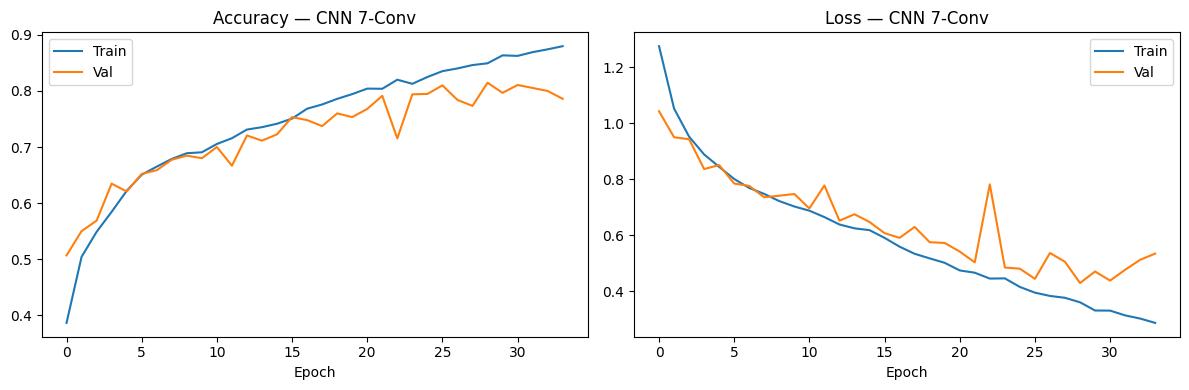

Training curves saved.


In [4]:
# ================================================
# Cell 4 — Training  (AMP + early stopping + save best)
# ================================================
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_custom_7cnn_model.pth")

# AMP: float16 training with GradScaler
scaler_amp        = torch.cuda.amp.GradScaler()

# Track best val_loss; save model whenever it improves
best_val_loss     = float('inf')
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []


# ── Training loop: train -> validate -> early stop -> save best ──
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


# Plot and save training/validation accuracy and loss per epoch
# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label='Train'); axes[0].plot(val_acc_hist, label='Val')
axes[0].set_title("Accuracy — CNN 7-Conv"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(train_loss_hist, label='Train'); axes[1].plot(val_loss_hist, label='Val')
axes[1].set_title("Loss — CNN 7-Conv"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")


     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/94 [00:00<?, ?it/s]

     0             0             0       YES
     1             0             0       YES
     2             0             0       YES
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0             0       YES
     8             0             0       YES
     9             0             0       YES
    10             0             0       YES
    11             0             0       YES
    12             0             0       YES
    13             0             0       YES
    14             0             0       YES
    15             0             0       YES
    16             0           500       NO 
    17             0             0       YES
    18             0           500       NO 
    19             0             0       YES
    20             0             0       YES
    21             0             0       YES
    22    

/tmp/ipykernel_32209/4257424649.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    64             0             0       YES
    65             0             0       YES
    66             0             0       YES
    67             0             0       YES
    68             0             0       YES
    69             0             0       YES
    70             0             0       YES
    71             0          1000       NO 
    72             0          1000       NO 
    73             0          1000       NO 
    74             0          1000       NO 
    75             0             0       YES
    76             0             0       YES
    77             0          1000       NO 
    78             0             0       YES
    79             0             0       YES
    80             0             0       YES
    81             0             0       YES
    82             0           500       NO 
    83             0             0       YES
    84             0             0       YES
    85             0             0       YES
    86    

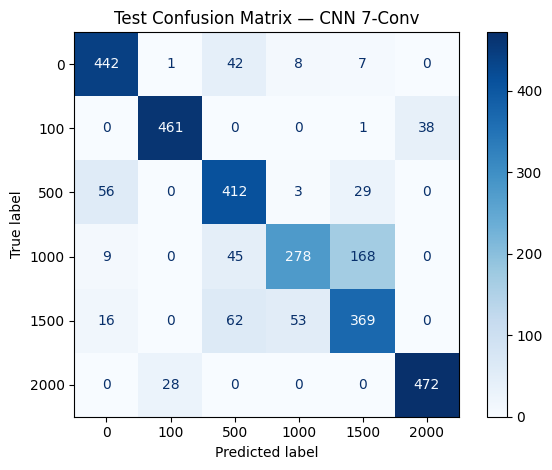


Classification Report — CNN 7-Conv:
              precision    recall  f1-score   support

           0     0.8451    0.8840    0.8641       500
         100     0.9408    0.9220    0.9313       500
         500     0.7344    0.8240    0.7766       500
        1000     0.8129    0.5560    0.6603       500
        1500     0.6429    0.7380    0.6872       500
        2000     0.9255    0.9440    0.9347       500

    accuracy                         0.8113      3000
   macro avg     0.8169    0.8113    0.8090      3000
weighted avg     0.8169    0.8113    0.8090      3000



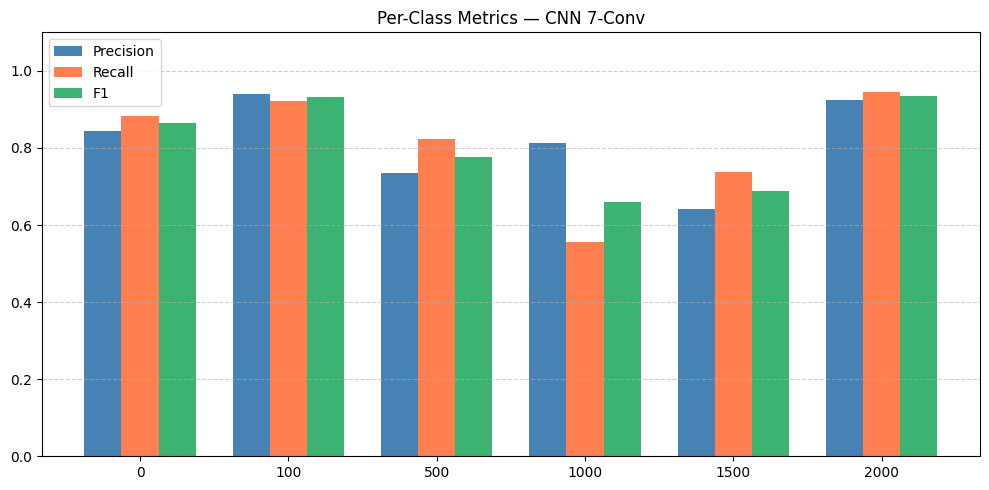

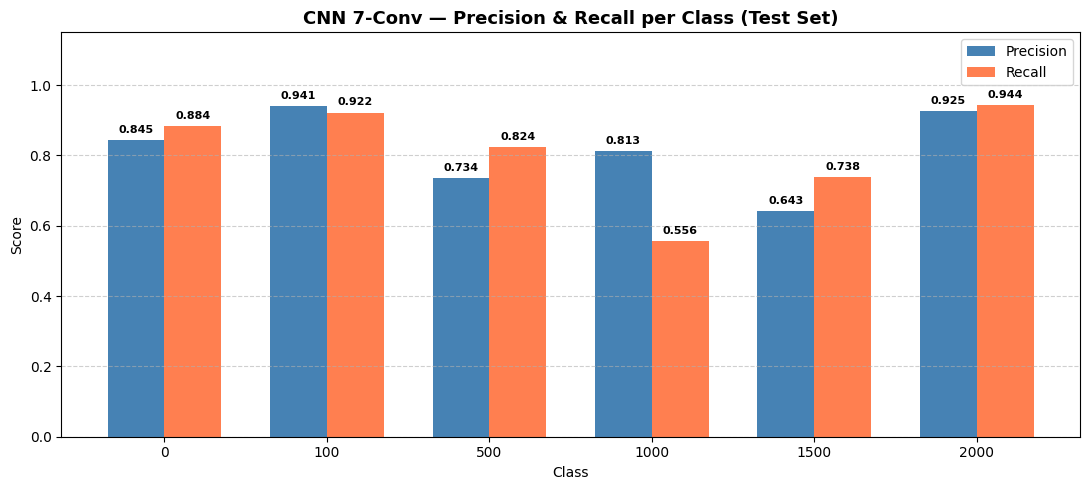

CNN Precision & Recall chart saved.


/tmp/ipykernel_32209/4257424649.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_32209/4257424649.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



CNN 7-Conv — Inference Time (100 random samples)
  Average : 2.672 ms / sample
  Std Dev : 0.063 ms
  Min     : 2.623 ms
  Max     : 3.178 ms
CNN inference times saved.


In [5]:
# ================================================
# Cell 5 — CNN Test Evaluation + Inference Print
# ================================================
import time

# Load best checkpoint (lowest val_loss) for evaluation
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct   = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (CNN 7-Conv): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# Confusion matrix across all 6 milling classes
# ── Confusion Matrix ──
cm   = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — CNN 7-Conv")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_cnn.png"), dpi=150)
plt.show()


# Per-class precision, recall, F1 — saved as .txt and .csv
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — CNN 7-Conv:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_cnn.txt"), "w") as f:
    f.write(report_txt)
pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, "classification_report_cnn.csv"))


# Grouped bar charts: Precision / Recall / F1 per class
# ── Per-class metrics ──
cnn_precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
cnn_recall    = recall_score(all_labels,    all_preds, average=None, labels=range(NUM_CLASSES))
cnn_f1        = f1_score(all_labels,        all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, cnn_precision, w, label='Precision', color='steelblue')
plt.bar(x,     cnn_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, cnn_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — CNN 7-Conv")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_cnn.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, cnn_precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, cnn_recall,    w2, label='Recall',    color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, cnn_precision[i] + 0.02, f'{cnn_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, cnn_recall[i]    + 0.02, f'{cnn_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 7-Conv — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_cnn.png"), dpi=150)
plt.show()
print("CNN Precision & Recall chart saved.")


# Per-sample true label, predicted label, correct flag
# ── Raw predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct":    (all_preds == all_labels).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, "predictions_cnn.csv"), index=False)

# ================================================
# CNN Inference Time — 100 random test samples
# ================================================
_rng100        = np.random.RandomState(SEED)
_sample_idx    = _rng100.choice(len(test_ds), 100, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0)

with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    with torch.cuda.amp.autocast():
        _ = model(_warm.to(DEVICE))
torch.cuda.synchronize()

cnn_times_ms = []
model.eval()
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast():
            _ = model(_inp)
        torch.cuda.synchronize()
        cnn_times_ms.append((time.perf_counter() - _t0) * 1000)

cnn_avg_time_ms = float(np.mean(cnn_times_ms))
cnn_std_time_ms = float(np.std(cnn_times_ms))

print("\n" + "="*52)
print("CNN 7-Conv — Inference Time (100 random samples)")
print("="*52)
print(f"  Average : {cnn_avg_time_ms:.3f} ms / sample")
print(f"  Std Dev : {cnn_std_time_ms:.3f} ms")
print(f"  Min     : {np.min(cnn_times_ms):.3f} ms")
print(f"  Max     : {np.max(cnn_times_ms):.3f} ms")
print("="*52)

pd.DataFrame({"sample": range(100), "cnn_time_ms": cnn_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "cnn_inference_times.csv"), index=False)
print("CNN inference times saved.")

In [6]:
# ================================================
# Cell 6 — Feature Extraction  (save embeddings)
# ================================================
# ── Feature extraction ─────────────────────────────────────────
# Extracts 512-d embeddings (fc1 output — same dimension as CNN6).
# Saved as .npy for mRMR (K=96), SVM training, and PCA analysis.
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE)
            with torch.cuda.amp.autocast():
                _, emb = model(inputs, return_embedding=True)  # (B, 128)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

train_embs, train_y = extract_embeddings(train_loader, model, "train")
val_embs,   val_y   = extract_embeddings(val_loader,   model, "val")
test_embs,  test_y  = extract_embeddings(test_loader,  model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [("train_embs", train_embs), ("val_embs",  val_embs),
                  ("test_embs",  test_embs),  ("train_y",   train_y),
                  ("val_y",      val_y),       ("test_y",    test_y)]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")

Extracting [train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_32209/3616339946.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Extracting [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding shapes -> train: (10500, 512)  val: (1500, 512)  test: (3000, 512)
  Saved train_embs.npy  shape=(10500, 512)
  Saved val_embs.npy  shape=(1500, 512)
  Saved test_embs.npy  shape=(3000, 512)
  Saved train_y.npy  shape=(10500,)
  Saved val_y.npy  shape=(1500,)
  Saved test_y.npy  shape=(3000,)

All embeddings saved.


Running mRMR: 12000 samples, 512 features -> selecting K=96 ...


/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 10 selected features (by MI):
 feature_index       mi
           243 0.988292
           476 0.984458
           115 0.967405
           164 0.966457
           237 0.965113
           116 0.943294
           494 0.927659
           406 0.921600
           280 0.919729
            12 0.916585


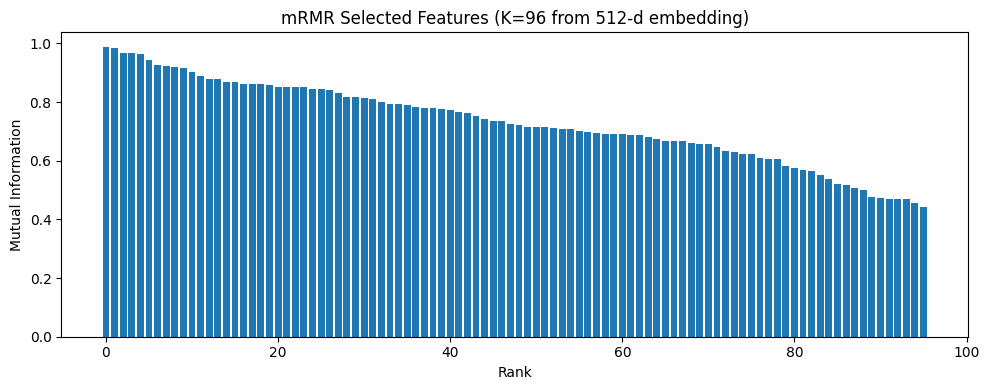

Reduced embedding: 96-d


In [7]:
# ================================================
# Cell 7 — mRMR Feature Selection
# ================================================
# ── mRMR greedy feature selection ──────────────────────────────
# Selects K=96 from the 512-d embedding — same as CNN6.
# Greedy: MI(feature, label) minus mean correlation with selected.
def mrmr_select(X, y, k, seed=SEED):
    """
    Greedy mRMR:
      relevance  = MI(feature, label)
      redundancy = mean |corr| to already-selected features
      score      = relevance - redundancy
    """
    X, y = np.asarray(X), np.asarray(y)
    k    = min(k, X.shape[1])
    mi   = mutual_info_classif(X, y, random_state=seed, discrete_features=False)
    corr = np.nan_to_num(np.abs(np.corrcoef(X, rowvar=False)), nan=0.0)

    selected  = [int(np.argmax(mi))]
    candidate = set(range(X.shape[1])) - set(selected)

    while len(selected) < k and candidate:
        scores    = {f: mi[f] - np.mean(corr[f, selected]) for f in candidate}
        best_feat = max(scores, key=scores.get)
        selected.append(best_feat)
        candidate.remove(best_feat)

    return selected, mi


# Combine train+val for more reliable MI estimation
X_tv = np.vstack([train_embs, val_embs])
y_tv = np.hstack([train_y,   val_y])

print(f"Running mRMR: {X_tv.shape[0]} samples, {X_tv.shape[1]} features -> selecting K={K_MRMR} ...")
selected_idx, mi = mrmr_select(X_tv, y_tv, k=K_MRMR)

sel_df = (pd.DataFrame({"feature_index": selected_idx, "mi": mi[selected_idx]})
            .sort_values("mi", ascending=False).reset_index(drop=True))
sel_df.to_csv(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}.csv"), index=False)

print(f"\nTop 10 selected features (by MI):")
print(sel_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(range(len(selected_idx)), sel_df["mi"].values)
plt.xlabel("Rank"); plt.ylabel("Mutual Information")
plt.title(f"mRMR Selected Features (K={K_MRMR} from 512-d embedding)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}_plot.png"), dpi=150)
plt.show()


# Reduce 512-d to 96-d using mRMR-selected indices
train_sel = train_embs[:, selected_idx]
val_sel   = val_embs[:,   selected_idx]
test_sel  = test_embs[:,  selected_idx]
print(f"Reduced embedding: {train_sel.shape[1]}-d")

Training SVM (RBF, C=10) ...
SVM training done.

SVM INFERENCE — per sample
     #    True Label    Pred Label   Correct
     0             0             0       YES
     1             0             0       YES
     2             0             0       YES
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0           500       NO 
     8             0             0       YES
     9             0             0       YES
    10             0             0       YES
    11             0             0       YES
    12             0             0       YES
    13             0             0       YES
    14             0             0       YES
    15             0             0       YES
    16             0           500       NO 
    17             0             0       YES
    18             0           500       NO 
    19             0    

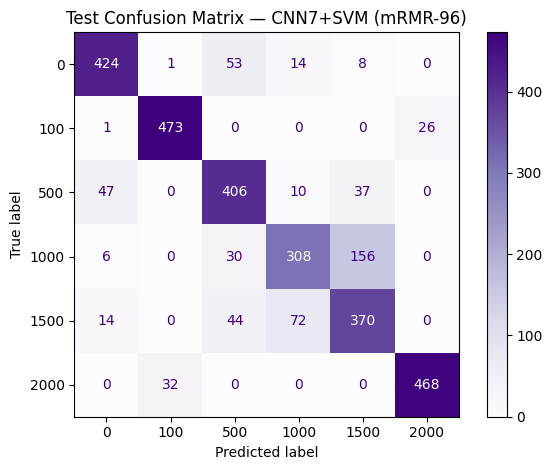


Classification Report — CNN7+SVM (mRMR-96):
              precision    recall  f1-score   support

           0     0.8618    0.8480    0.8548       500
         100     0.9348    0.9460    0.9404       500
         500     0.7617    0.8120    0.7861       500
        1000     0.7624    0.6160    0.6814       500
        1500     0.6480    0.7400    0.6909       500
        2000     0.9474    0.9360    0.9416       500

    accuracy                         0.8163      3000
   macro avg     0.8193    0.8163    0.8159      3000
weighted avg     0.8193    0.8163    0.8159      3000



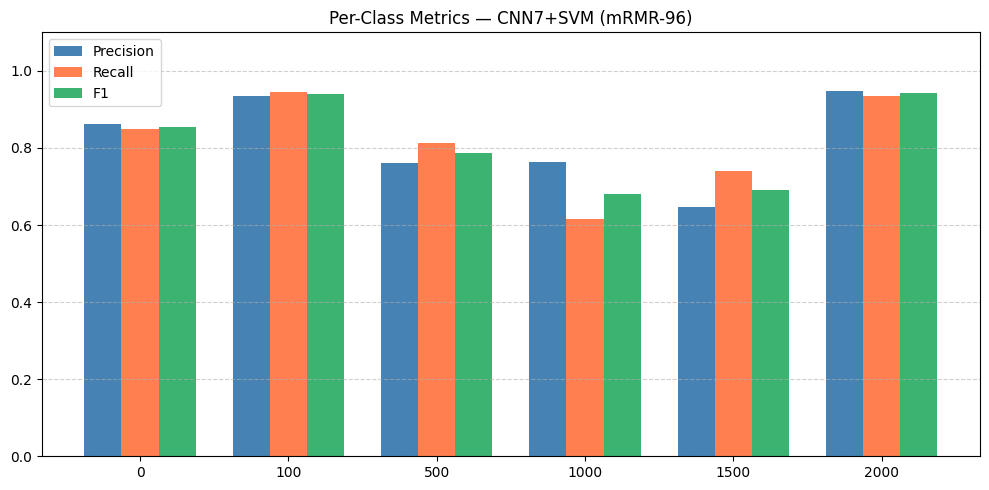

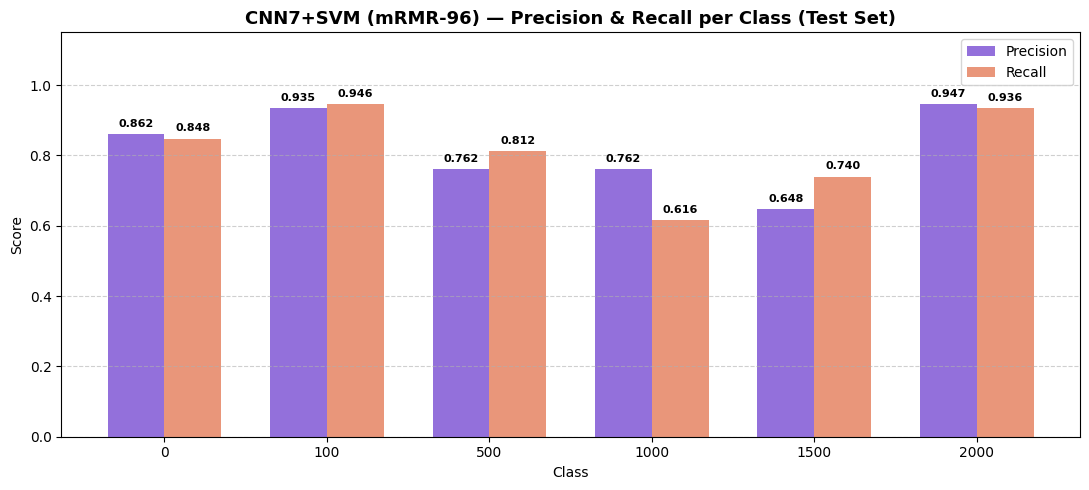

SVM Precision & Recall chart saved.


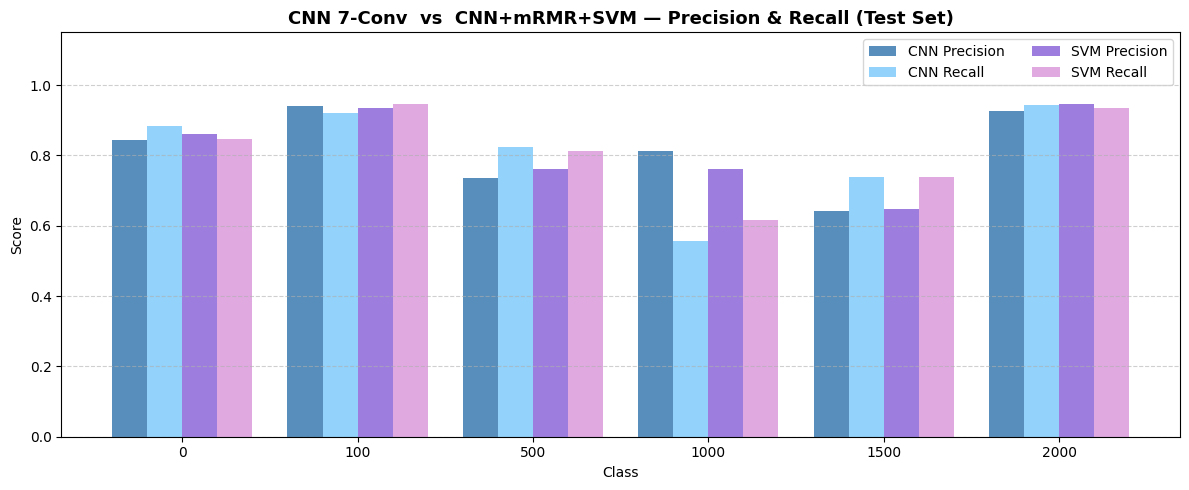

CNN vs SVM comparison chart saved.

SVM (mRMR-96) — Inference Time (100 random samples)
  Average : 0.3013 ms / sample
  Std Dev : 0.0345 ms
  Min     : 0.2656 ms
  Max     : 0.4412 ms

INFERENCE TIME SUMMARY (avg over 100 samples)
  CNN alone        : 2.672 ± 0.063 ms
  SVM alone (mRMR) : 0.3013 ± 0.0345 ms
  Full pipeline    : 2.973 ms  (CNN + SVM)

All artifacts saved in: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN7_May11_Results
best_custom_7cnn_model.pth
classification_report_cnn.csv
classification_report_cnn.txt
classification_report_svm_mrmr_96.csv
classification_report_svm_mrmr_96.txt
cnn_inference_times.csv
comparison_cnn_vs_svm_precision_recall.png
confusion_matrix_cnn.png
confusion_matrix_svm_mrmr_96.png
inference_time_summary.csv
mrmr_selected_96.csv
mrmr_selected_96_plot.png
per_class_metrics_cnn.png
per_class_metrics_svm_mrmr_96.png
precision_recall_cnn.png
precision_recall_svm_mrmr_96.png
predictions_cnn.csv
predictions_svm_mrmr_96.csv
scaler_mrmr_svm.joblib

In [8]:
# ================================================
# Cell 8 — SVM Training + Evaluation + Inference
# ================================================
# ── SVM pipeline ───────────────────────────────────────────────
# StandardScaler normalises 96-d features; fitted on train+val only.
scaler       = StandardScaler()
train_std    = scaler.fit_transform(np.vstack([train_sel, val_sel]))
test_std     = scaler.transform(test_sel)
y_train_full = np.hstack([train_y, val_y])

print("Training SVM (RBF, C=10) ...")
svm = SVC(kernel="rbf", C=10.0, gamma="scale", probability=False, random_state=SEED)
svm.fit(train_std, y_train_full)
print("SVM training done.")


# Save scaler and SVM for future inference
dump(scaler, os.path.join(OUTPUT_DIR, "scaler_mrmr_svm.joblib"))
dump(svm,    os.path.join(OUTPUT_DIR, "svm_mrmr_rbf.joblib"))


# Run SVM predictions on the full test set
# ── SVM Inference per sample ──
svm_preds = svm.predict(test_std)

print("\n" + "="*65)
print("SVM INFERENCE — per sample")
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)
for i, (true, pred) in enumerate(zip(test_y, svm_preds)):
    correct = "YES" if true == pred else "NO "
    print(f"{i:>6}  {CLASS_NAMES[true]:>12}  {CLASS_NAMES[pred]:>12}  {correct:>8}")
print("="*65)

svm_acc = (svm_preds == test_y).mean()
print(f"\nTest Accuracy (CNN7 + mRMR-{K_MRMR} + SVM): {svm_acc * 100:.2f}%")
print(f"Correct: {(svm_preds == test_y).sum()} / {len(test_y)}")


# Confusion matrix across all 6 milling classes
# ── Confusion Matrix ──
cm_svm = confusion_matrix(test_y, svm_preds, labels=list(range(NUM_CLASSES)))
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=CLASS_NAMES)
disp.plot(cmap='Purples', values_format='d')
plt.title(f"Test Confusion Matrix — CNN7+SVM (mRMR-{K_MRMR})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()


# Per-class precision, recall, F1 — saved as .txt and .csv
# ── Classification Report ──
rep_txt = classification_report(test_y, svm_preds, target_names=CLASS_NAMES, digits=4)
print(f"\nClassification Report — CNN7+SVM (mRMR-{K_MRMR}):")
print(rep_txt)
with open(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.txt"), "w") as f:
    f.write(rep_txt)
pd.DataFrame(
    classification_report(test_y, svm_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.csv"))


# Grouped bar charts: Precision / Recall / F1 per class
# ── Per-class metrics ──
svm_precision = precision_score(test_y, svm_preds, average=None, labels=range(NUM_CLASSES))
svm_recall    = recall_score(test_y,    svm_preds, average=None, labels=range(NUM_CLASSES))
svm_f1        = f1_score(test_y,       svm_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 (SVM) ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, svm_precision, w, label='Precision', color='steelblue')
plt.bar(x,     svm_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, svm_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title(f"Per-Class Metrics — CNN7+SVM (mRMR-{K_MRMR})")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"per_class_metrics_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart (SVM) ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, svm_precision, w2, label='Precision', color='mediumpurple')
plt.bar(x + w2/2, svm_recall,    w2, label='Recall',    color='darksalmon')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, svm_precision[i] + 0.02, f'{svm_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, svm_recall[i]    + 0.02, f'{svm_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title(f"CNN7+SVM (mRMR-{K_MRMR}) — Precision & Recall per Class (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"precision_recall_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()
print("SVM Precision & Recall chart saved.")


# CNN vs SVM comparison chart — per-class precision and recall
# ── Chart 3: CNN vs SVM comparison (Precision & Recall same chart) ──
w3 = 0.2
plt.figure(figsize=(12, 5))
plt.bar(x - 1.5*w3, cnn_precision, w3, label='CNN Precision',     color='steelblue',    alpha=0.9)
plt.bar(x - 0.5*w3, cnn_recall,    w3, label='CNN Recall',        color='lightskyblue', alpha=0.9)
plt.bar(x + 0.5*w3, svm_precision, w3, label='SVM Precision',     color='mediumpurple', alpha=0.9)
plt.bar(x + 1.5*w3, svm_recall,    w3, label='SVM Recall',        color='plum',         alpha=0.9)
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 7-Conv  vs  CNN+mRMR+SVM — Precision & Recall (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(ncol=2); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_cnn_vs_svm_precision_recall.png"), dpi=150)
plt.show()
print("CNN vs SVM comparison chart saved.")

# ── Predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(test_y)),
    "True Label": [CLASS_NAMES[i] for i in test_y],
    "Pred Label": [CLASS_NAMES[i] for i in svm_preds],
    "Correct":    (svm_preds == test_y).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, f"predictions_svm_mrmr_{K_MRMR}.csv"), index=False)

# ================================================
# SVM Inference Time — same 100 random test samples
# ================================================
_rng100     = np.random.RandomState(SEED)
_sample_idx = _rng100.choice(len(test_y), 100, replace=False)
_test_100   = test_std[_sample_idx]

_ = svm.predict(_test_100[:1])   # warm-up

svm_times_ms = []
for i in range(100):
    _t0 = time.perf_counter()
    _   = svm.predict(_test_100[i : i + 1])
    svm_times_ms.append((time.perf_counter() - _t0) * 1000)

svm_avg_time_ms = float(np.mean(svm_times_ms))
svm_std_time_ms = float(np.std(svm_times_ms))

print("\n" + "="*55)
print(f"SVM (mRMR-{K_MRMR}) — Inference Time (100 random samples)")
print("="*55)
print(f"  Average : {svm_avg_time_ms:.4f} ms / sample")
print(f"  Std Dev : {svm_std_time_ms:.4f} ms")
print(f"  Min     : {np.min(svm_times_ms):.4f} ms")
print(f"  Max     : {np.max(svm_times_ms):.4f} ms")
print("="*55)

pd.DataFrame({"sample": range(100), "svm_time_ms": svm_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, f"svm_inference_times_{K_MRMR}.csv"), index=False)


# Inference time: CNN alone / SVM alone / full pipeline
# ── Final Summary ──
pipeline_avg = cnn_avg_time_ms + svm_avg_time_ms
print("\n" + "="*55)
print("INFERENCE TIME SUMMARY (avg over 100 samples)")
print("="*55)
print(f"  CNN alone        : {cnn_avg_time_ms:.3f} ± {cnn_std_time_ms:.3f} ms")
print(f"  SVM alone (mRMR) : {svm_avg_time_ms:.4f} ± {svm_std_time_ms:.4f} ms")
print(f"  Full pipeline    : {pipeline_avg:.3f} ms  (CNN + SVM)")
print("="*55)

pd.DataFrame({
    "Stage":   ["CNN only", f"SVM mRMR-{K_MRMR}", "Full Pipeline"],
    "Avg_ms":  [round(cnn_avg_time_ms, 4), round(svm_avg_time_ms, 4), round(pipeline_avg, 4)],
    "Std_ms":  [round(cnn_std_time_ms, 4), round(svm_std_time_ms, 4), "-"],
}).to_csv(os.path.join(OUTPUT_DIR, "inference_time_summary.csv"), index=False)

print("\n" + "="*50)
print("All artifacts saved in:", OUTPUT_DIR)
print("="*50)
print(os.linesep.join(sorted(os.listdir(OUTPUT_DIR))))

Embeddings : (3000, 512)
True labels: (3000,)
Classes    : ['0', '100', '500', '1000', '1500', '2000']
PCA output : /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN7_May11_Results/PCA_Analysis

Explained variance: PC1=0.453  PC2=0.288  Total=0.741


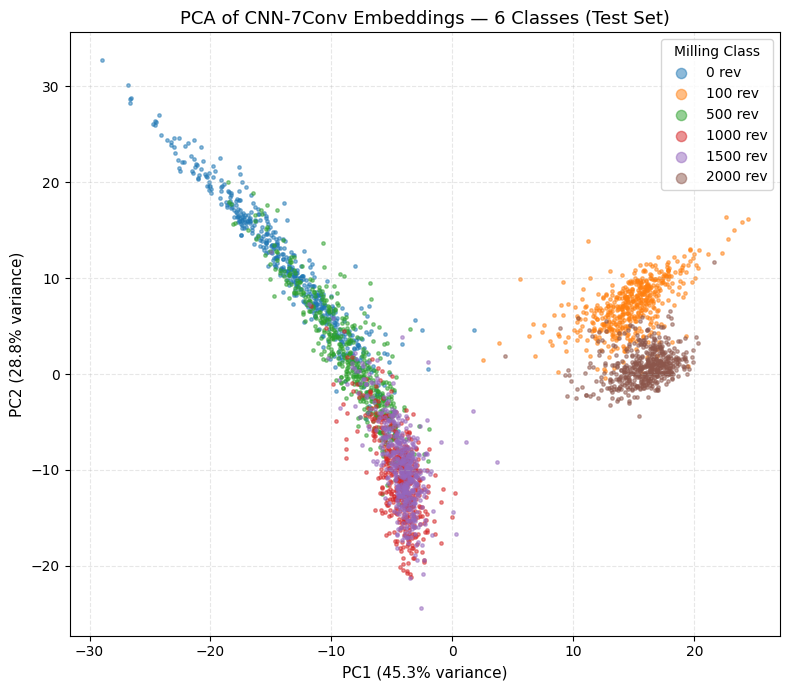

Saved: pca_embeddings.png


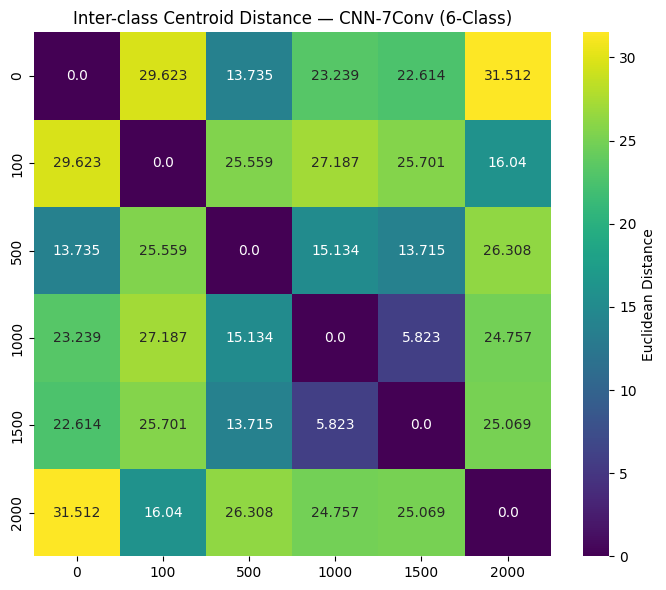

Saved: distance_heatmap.png


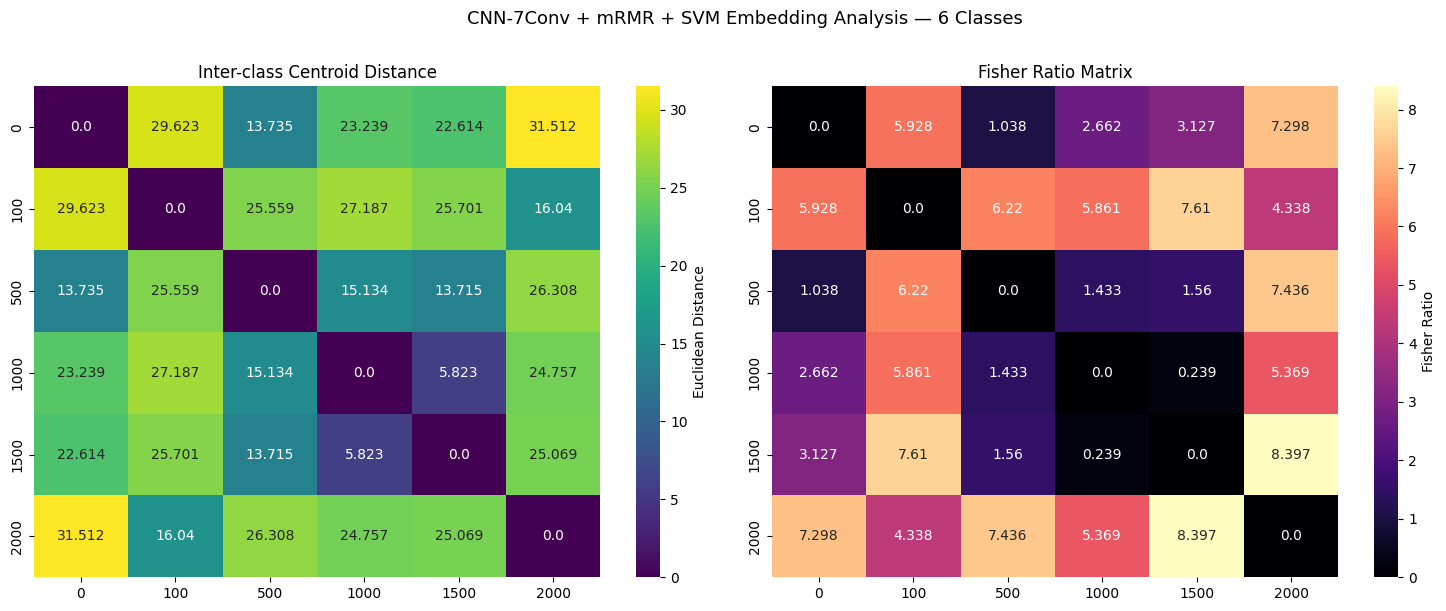

Saved: distance_fisher_side_by_side.png


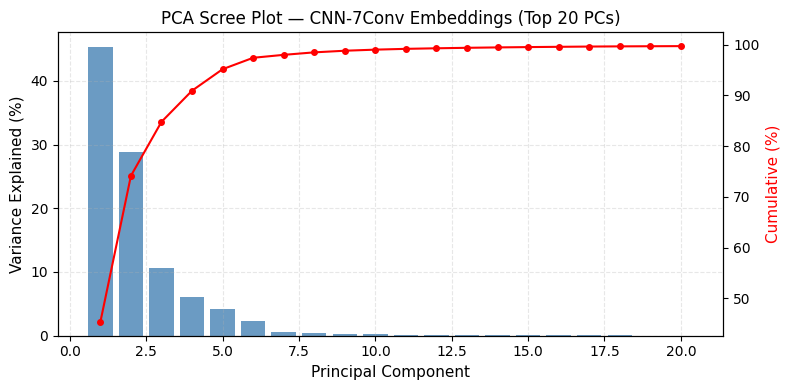

Saved: pca_scree_plot.png

All PCA results saved to: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN7_May11_Results/PCA_Analysis
PC1+PC2 explains : 74.1%
PCs for 95% var  : 5


In [9]:
# ================================================
# Cell 9 — PCA Analysis of CNN Embeddings
# ================================================
# seaborn/scipy/sklearn PCA: heatmaps, centroid distances, 2D projection
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from glob import glob

PCA_DIR = os.path.join(OUTPUT_DIR, "PCA_Analysis")
os.makedirs(PCA_DIR, exist_ok=True)


# Load 512-d CNN7 embeddings for PCA.
# Despite similar embedding dimension to CNN6, cluster separation
# may be weaker — consistent with CNN7's lower accuracy.
# Load CNN embeddings saved by Cell 6
test_embs = np.load(os.path.join(OUTPUT_DIR, "test_embs.npy"))
y_true    = np.load(os.path.join(OUTPUT_DIR, "test_y.npy"))

# Find predictions CSV (SVM predictions saved by Cell 8)
pred_csvs = glob(os.path.join(OUTPUT_DIR, "predictions_*.csv"))
assert pred_csvs, f"No predictions CSV found in {OUTPUT_DIR}. Run Cell 8 first."
pred_df      = pd.read_csv(pred_csvs[0])
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
y_pred = np.array([label_to_idx[str(l)] for l in pred_df["Pred Label"].values])

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'][:NUM_CLASSES]

print(f"Embeddings : {test_embs.shape}")
print(f"True labels: {y_true.shape}")
print(f"Classes    : {CLASS_NAMES}")
print(f"PCA output : {PCA_DIR}")


# ── PCA 2-D projection ─────────────────────────────────────────
# Projects 512-d embeddings to 2 PCs for class separation analysis.
# ── PCA 2D scatter ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(test_embs)
var = pca.explained_variance_ratio_
print(f"\nExplained variance: PC1={var[0]:.3f}  PC2={var[1]:.3f}  Total={var.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i, name in enumerate(CLASS_NAMES):
    idx = (y_true == i)
    ax.scatter(Z[idx, 0], Z[idx, 1], s=6, alpha=0.5, label=f'{name} rev', color=COLORS[i])
ax.set_title(f'PCA of CNN-7Conv Embeddings — {NUM_CLASSES} Classes (Test Set)', fontsize=13)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', fontsize=11)
ax.legend(markerscale=3, fontsize=10, title='Milling Class')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_embeddings.png"), dpi=300)
plt.show()
print("Saved: pca_embeddings.png")


# Inter-class centroid Euclidean distances in 512-d embedding space
# ── Centroid distances ──────────────────────────
centroids, intra_spread = [], []
for i in range(NUM_CLASSES):
    Xc = test_embs[y_true == i]
    mu = Xc.mean(axis=0)
    centroids.append(mu)
    intra_spread.append(np.mean(np.linalg.norm(Xc - mu, axis=1)))
centroids    = np.vstack(centroids)
intra_spread = np.array(intra_spread)

inter   = cdist(centroids, centroids, metric='euclidean')
dist_df = pd.DataFrame(inter, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title(f'Inter-class Centroid Distance — CNN-7Conv ({NUM_CLASSES}-Class)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_heatmap.png"), dpi=300)
plt.show()
print("Saved: distance_heatmap.png")


# Fisher ratio + distance heatmaps side by side for paper figure
# ── Fisher ratio + side-by-side ─────────────────
intra_var = intra_spread ** 2
F = np.zeros((NUM_CLASSES, NUM_CLASSES))
for a in range(NUM_CLASSES):
    for b in range(NUM_CLASSES):
        if a != b:
            F[a, b] = (inter[a, b] ** 2) / (intra_var[a] + intra_var[b] + 1e-8)
fish_df = pd.DataFrame(F, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'Euclidean Distance'})
axes[0].set_title('Inter-class Centroid Distance', fontsize=12)
sns.heatmap(fish_df.round(3), annot=True, fmt='', cmap='magma', ax=axes[1],
            cbar_kws={'label': 'Fisher Ratio'})
axes[1].set_title('Fisher Ratio Matrix', fontsize=12)
fig.suptitle(f'CNN-7Conv + mRMR + SVM Embedding Analysis — {NUM_CLASSES} Classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_fisher_side_by_side.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: distance_fisher_side_by_side.png")


# PCA scree: variance per component and cumulative variance
# ── Scree plot ──────────────────────────────────
pca_full = PCA(random_state=42).fit(test_embs)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax  = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100, color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(range(1, 21), cum_var[:20]*100, color='red', marker='o', ms=4)
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_ylabel('Cumulative (%)', fontsize=11, color='red')
ax.set_title('PCA Scree Plot — CNN-7Conv Embeddings (Top 20 PCs)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_scree_plot.png"), dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")


# Export all PCA metrics to CSV for reproducibility
# ── Save CSVs ───────────────────────────────────
dist_df.to_csv(os.path.join(PCA_DIR, "pairwise_centroid_distance.csv"))
fish_df.to_csv(os.path.join(PCA_DIR, "pairwise_fisher_ratio.csv"))
pd.DataFrame({'Class': CLASS_NAMES, 'Intra_spread': intra_spread.round(4),
              'N_samples': [int(np.sum(y_true == i)) for i in range(NUM_CLASSES)]
}).to_csv(os.path.join(PCA_DIR, "class_spread_summary.csv"), index=False)
pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
              'True_Label': [CLASS_NAMES[i] for i in y_true]
}).to_csv(os.path.join(PCA_DIR, "pca_coordinates.csv"), index=False)

n_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"\nAll PCA results saved to: {PCA_DIR}")
print(f"PC1+PC2 explains : {cum_var[1]*100:.1f}%")
print(f"PCs for 95% var  : {n_95}")